Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°6**
##**Tema**: Aplicaciones de AG - Tachos##

## Ejercicio 1
Se tiene el siguiente modelo simplificado del funcionamiento de un sector de una fábrica de azúcar: Se tienen **N** tachos de cocimiento, cada uno de los cuales consume vapor de una determinada manera a lo largo del tiempo. El consumo total de vapor puede calcularse como la suma del consumo de vapor individual de cada tacho. El tiempo entre que empieza a consumir el primer tacho hasta que deja de consumir el último tacho es **tMAX** (llamado tiempo total del ciclo o *timespan*). Durante este tiempo, el consumo de vapor varía en el tiempo, consumiendo mayor energía mientras mayor sea esta variación. Este problema consiste en reducir la energía que se consume por la variación de vapor a lo largo del ciclo de cocimiento de la azúcar. A continuación se brindan detalles del modelado del problema:


Un tacho de cocimiento consume vapor durante un lapso de tiempo. El proceso arranca en el tiempo t0, y finaliza en t1 = t0+1 donde ya se consumió todo el vapor del tacho. Es decir, el proceso dura *una unidad de tiempo*. Este comportamiento se puede modelar como una parábola con las ramas hacia abajo, donde alcanza su máximo en t = 1, y está definida en el intervalo  t0 ≤ t ≤ t0+1, siendo nulo fuera de dicho intervalo. Es decir:

  * VaporTacho_i(t) = **0**, *si 0 ≤ t ≤ t0*
  * VaporTacho_i(t) = **1 - (2 * t0 - 2t + 1)^2**, *si t0 ≤ t ≤ t0+1*
  * VaporTacho_i(t) = **0**, *si t1 ≤ t ≤ tMAX*








Consumo de vapor para un tacho, tomando como ejemplo t0 = 1.000000


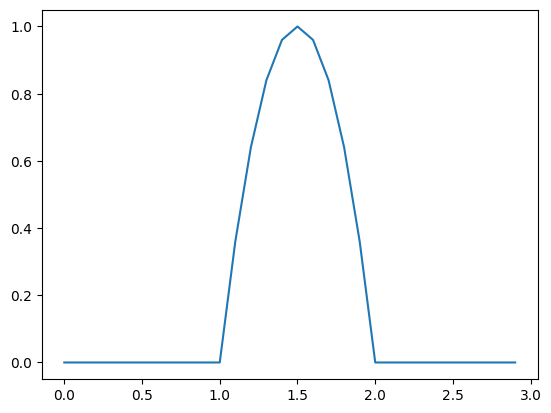

In [ ]:
def VaporTacho_i(t, t0):
  return 1 - (2*t0-2*t + 1)**2 if t > t0 and t < t0+1 else 0

import matplotlib.pyplot as plt
t0 = 1
intervalo = [x/10 for x in range(30)]
vt = [VaporTacho_i(t,t0) for t in intervalo]
plt.figure()
plt.plot(intervalo, vt);
print('Consumo de vapor para un tacho, tomando como ejemplo t0 = %f'%t0)

Ahora suponga que la fábrica cuenta con una cantidad de tachos de cocimiento **N** que puede variar entre 5 y 20. Los tachos arrancan de manera
independiente entre ellos, y el vapor total puede ser calculado en cada instante de tiempo sumando el vapor producido por cada tacho. Es decir:

* VaporTotal(t) = SUM_i { VaporTacho_i(t) }

Consumo de vapor total con dos tachos, tomando como ejemplo t0 = 0.800000 y t0=1.100000


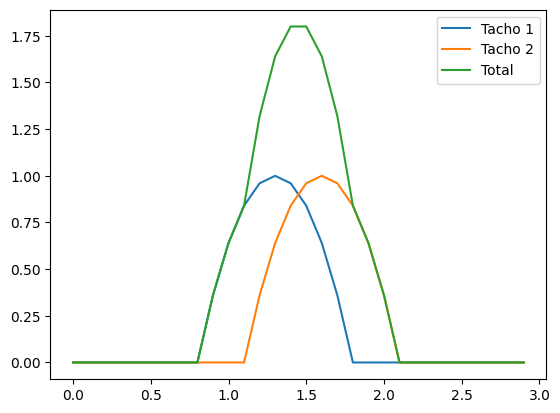

In [2]:
def VaporTotal(t_inicios, intervalo):
  return [sum([VaporTacho_i(t,t0) for t0 in t_inicios]) for t in intervalo]

t0_1 = 0.8
t0_2 = 1.1
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
vtotal = VaporTotal([t0_1, t0_2], intervalo)
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
print('Consumo de vapor total con dos tachos, tomando como ejemplo t0 = %f y t0=%f'%(t0_1,t0_2))

El objetivo del problema es diseñar un Algoritmo Genético que organice el cronograma de arranques (*Schedule*) de los tachos, de manera que:
* Todos los tachos deben completar su ciclo.
* Se estabilizce el consumo de vapor total (que no existan grandes variaciones de vapor durante todo el proceso). Es decir, se prefieren soluciones que produzcan un consumo de vapor "*constante*".
* Se prefieren soluciones que brinden un tiempo total de funcionamiento menor.
* Se debe evitar la convergencia hacia las soluciones triviales e incorrectas:
* El algoritmo debe ser general, funcionando para diferente cantidad de tachos **N**.
  * Donde el tiempo total es mínimo debido a que todos los tachos arrancan juntos.
  * Los tachos arrancan uno despues de otro (no se superponen).



In [ ]:
t0_1 = 0.8
t0_2 = 0.8
t0_3 = 0.8
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
plt.plot(intervalo, vt3, label='Tacho 3');
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
plt.title('Tachos arrancando juntos')

t0_1 = 0
t0_2 = 1
t0_3 = 2
vt1 = [VaporTacho_i(t, t0_1) for t in intervalo]
vt2 = [VaporTacho_i(t, t0_2) for t in intervalo]
vt3 = [VaporTacho_i(t, t0_3) for t in intervalo]
vtotal = VaporTotal([t0_1, t0_2, t0_3], intervalo)
plt.figure()
plt.plot(intervalo, vt1, label='Tacho 1');
plt.plot(intervalo, vt2, label='Tacho 2');
plt.plot(intervalo, vt3, label='Tacho 3');
plt.plot(intervalo, vtotal, label='Total');
plt.legend()
plt.title('Tachos arrancando uno despues de otro')
print("Soluciones triviales a evitar:")

La función fitness, entonces, deberá tener en cuenta las variaciones de vapor total en el tiempo, y el tiempo total del ciclo.

In [ ]:
#Esta definicion de la función fitness es sólo ilustrativa, para dar una idea general de cómo implementarla

def fitnessTachos(x_vars):
  objetivo_1 = ... #medida de la variabilidad del vapor total (que sea lo más constante posible)
  objetivo_2 = ... #tiempo que dura todo el ciclo

  #COMPLETAR

  return ...


Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base a los objetivos del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidad de tachos presentes.

Funciones Necesarias para el Genetico


In [ ]:

import random

## Crossover
def cube_crossover(parent1, parent2):
    """
        parent1, parent2 listas de inicios de tiempos de los tachos de los padres

    """
    child1 = []
    child2 = []
    
    for p1, p2 in zip(parent1, parent2):
        rand = random.random()
        
        c1 = p1 + rand * (p2 - p1)
        c2 = p2 + rand * (p1 - p2)
        
        
        child1.append(c1)
        child2.append(c2)
        
    return child1, child2
